# Инициализация

Загружаем библиотеки необходимые для выполнения кода ноутбука.

In [1]:
import logging

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import sklearn.preprocessing
import random

from pandas.tseries.offsets import MonthEnd

In [2]:
%matplotlib inline
%config InlineBackend.figure_format = 'png'
%config InlineBackend.figure_format = 'retina'

# === ЭТАП 1 ===

# Загрузка первичных данных

Загружаем первичные данные из файлов:
- tracks.parquet
- catalog_names.parquet
- interactions.parquet

In [2]:
# Загрузим данные
tracks = pd.read_parquet("data/tracks.parquet")
catalog_names = pd.read_parquet("data/catalog_names.parquet")
interactions = pd.read_parquet("data/interactions.parquet")

# Обзор данных

Проверяем данные, есть ли с ними явные проблемы.

In [20]:
# Посмотрим на структуру данных
tracks.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 4 columns):
 #   Column    Non-Null Count    Dtype 
---  ------    --------------    ----- 
 0   track_id  1000000 non-null  int64 
 1   albums    1000000 non-null  object
 2   artists   1000000 non-null  object
 3   genres    1000000 non-null  object
dtypes: int64(1), object(3)
memory usage: 30.5+ MB


In [ ]:
# Посмотрим на данные
tracks.sample(3)

,track_id,albums,artists,genres
256586,15876476,[1730681],[226833],"[15, 25]"
738612,55559111,[8133728],"[7749777, 5999454, 6092198, 7749778, 7749779]",[25]
688494,50504756,"[6978053, 10459522]",[6347797],"[3, 75]"


In [ ]:
# Проверим дубликаты
tracks.track_id.duplicated().sum()

0

In [3]:
# Проверим наличие пустых массивов в строках
has_empty_array = tracks[['albums','artists','genres']].apply(lambda row: any(arr.size == 0 for arr in row), axis=1)

# Вывод строк с пустыми массивами
empty_array_rows = tracks[has_empty_array]

print(f'Количество строк с пустыми массивами: {round(empty_array_rows.shape[0]/tracks.shape[0]*100, 2)} %')
display(empty_array_rows)

Количество строк с пустыми массивами: 1.9 %


,track_id,albums,artists,genres
490,2520,"[249, 163801, 163802, 324616, 17542430, 189498...",[2259],[]
3069,16776,"[1479, 5319, 6093, 8467, 10641, 90867, 163801,...",[978],[]
3077,16801,"[1479, 163801, 9287549, 9377183, 9424994, 1201...",[10520],[]
4192,23752,"[2001, 3722, 4973, 6104, 6558, 23866, 37052, 7...",[13373],[]
6645,38012,"[3147, 60099, 530836, 1115289, 2490724, 818446...",[16758],[]
...,...,...,...,...
999868,101201589,[12649219],[],"[62, 77]"
999876,101219571,[9444321],[],"[62, 83, 77]"
999901,101243616,[11700332],[],"[62, 93]"
999920,101292599,[9331881],[],"[62, 90, 77, 84]"


Данных с пропусками менее 2 процентов. Их можно удалить.

In [4]:
# Удалим пропуски
tracks_clean = tracks[~has_empty_array].reset_index(drop=True)

In [ ]:
# Сохраним очищенный датасет
tracks_clean.to_parquet('data/tracks_clean.parquet')

In [12]:
catalog_names.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1812471 entries, 0 to 1812470
Data columns (total 3 columns):
 #   Column  Dtype 
---  ------  ----- 
 0   id      int64 
 1   type    object
 2   name    object
dtypes: int64(1), object(2)
memory usage: 41.5+ MB


In [ ]:
# Выведем несколько строк
catalog_names.sample(3)

,id,type,name
1266246,31659246,track,Nl4m
45653,196307,album,Romance In Venice
413678,7872083,album,Double Damage


In [7]:
# Проверим количество дублирующихся каталожных единиц
print(catalog_names.id.duplicated().sum())

print(f'Количество дублирующихся каталожных единиц: {round(catalog_names.id.duplicated().sum() / catalog_names.shape[0] * 100, 2)} %')

35774
Количество дублирующихся каталожных единиц: 1.97 %


In [71]:
# Выведем пример дублирующихся данных
catalog_names[catalog_names['id'].isin([416037, 4428, 301328])].sort_values('id')

,id,type,name
1925,4428,album,"Tatum Group Masterpieces, Vol 2"
659819,4428,artist,Charles Aznavour
813477,4428,track,Heaven Must Have Sent You
56254,301328,album,Success Is Certain [Clean]
849141,301328,track,Running Free
682286,301328,artist,Dirty Red
60818,416037,album,ROCK ANTHEMS VOL-6
687015,416037,artist,The Snake
860021,416037,track,The Power of Thy Sword


Похоже, что в за дубликатами скрываются ошибки. Например, под id 416037  трек Manowar - The Power of Thy Sword, и под этим же id в наших данных указан другой исполнитель The Snake.

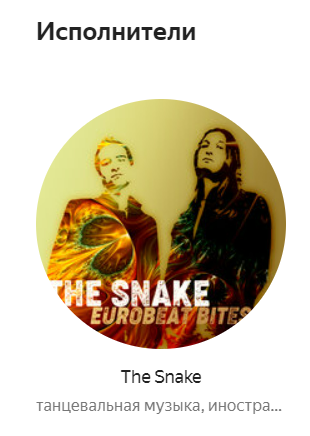

In [ ]:
# Удалим дубликаты в id
catalog_names_clean = catalog_names[~catalog_names.id.duplicated()].reset_index(drop=True)

In [49]:
# Проверим дублирующиеся строки
catalog_names[catalog_names.duplicated()]

,id,type,name


In [55]:
# Проверим наличие пропусков
catalog_names[catalog_names.isna().any(axis=1)]

,id,type,name


In [83]:
# Проверим "неизвестных" исполнителей
catalog_names[catalog_names['name']=='Unknown']

,id,type,name
55033,289114,album,Unknown
76078,601828,album,Unknown
228223,3477779,album,Unknown
358680,6152730,album,Unknown
360535,6192254,album,Unknown
414186,7891127,album,Unknown
504301,11271919,album,Unknown
554625,13364758,album,Unknown
561444,13723426,album,Unknown
643164,19671631,album,Unknown


Такой исполнитель есть на я.музыке, а альбомов и треков нет.

In [85]:
catalog_names[catalog_names['name']=='unknown']

,id,type,name
524817,12116653,album,unknown
526549,12190200,album,unknown
1682761,71240864,track,unknown


In [14]:
# Удалим неизвестных исполнителей, треки и альбомы
catalog_names_clean = catalog_names_clean[~catalog_names_clean['name'].isin(['unknown', 'Unknown'])].reset_index(drop=True)

In [16]:
catalog_names_clean.to_parquet('data/catalog_names_clean.parquet')

С названием unknown на сервисе ничего нет. Похоже, это заглушка.

In [86]:
# Посмотрим следующий датасет
interactions.info()

<class 'pandas.core.frame.DataFrame'>
Index: 222629898 entries, 0 to 291
Data columns (total 4 columns):
 #   Column      Dtype         
---  ------      -----         
 0   user_id     int32         
 1   track_id    int32         
 2   track_seq   int16         
 3   started_at  datetime64[ns]
dtypes: datetime64[ns](1), int16(1), int32(2)
memory usage: 5.4 GB


In [87]:
# Выведем несколько строк
interactions.sample(3)

,user_id,track_id,track_seq,started_at
1116,1174492,83979509,1117,2022-10-12
804,909095,54108162,805,2022-11-29
123,934811,4644164,124,2022-09-16


In [88]:
# Проверим наличие пропусков
interactions[interactions.isna().any(axis=1)]

,user_id,track_id,track_seq,started_at


In [89]:
# Проверим дублирующиеся строки
interactions[interactions.duplicated()]

,user_id,track_id,track_seq,started_at


In [91]:
# Посмотрим на самую раннюю дату
interactions['started_at'].min()

Timestamp('2022-01-01 00:00:00')

In [92]:
# Посмотрим на последнюю дату
interactions['started_at'].max()

Timestamp('2022-12-31 00:00:00')

Таким образом, данные о взаимодействиям предствалены за один год.

# Выводы

Данные о треках — в файле tracks.parquet:
- track_id — идентификатор музыкального трека;
- albums — список идентификаторов альбомов, содержащих трек;
- artists — список идентификаторов исполнителей трека;
- genres — список идентификаторов жанров, к которым принадлежит трек.

Имена артистов, названия альбомов, треков и жанров — в файле catalog_names.parquet:
- id — идентификатор одной из каталожных единиц (трека, альбома, исполнителя, жанра);
- type — тип идентификатора;
- name — имя (название) каталожной единицы.

Данные о том, какие пользователи прослушали тот или иной трек, — в файле interactions.parquet:
- user_id — идентификатор пользователя,
- track_id — идентификатор музыкального трека,
- track_seq — номер места трека в истории пользователя,
- started_at — дата начала прослушивания трека.

Приведём выводы по первому знакомству с данными:
- в датасете tracks есть пустые ячейки, а в датасете catalog_names есть дубликаты и строки с значениями "unknown".
- пропуски и дубликаты составляют менее 2% данных. Их можно удалить. 
- строки с значениями "unknown" тоже удалены, чтобы не вносить неопределенность в рекомендации.

# === ЭТАП 2 ===

# EDA

Распределение количества прослушанных треков.

In [4]:
# Сделаем признак месяца
interactions["started_at_month"] = pd.to_datetime(interactions["started_at"]).dt.to_period('M').dt.to_timestamp().dt.date

In [7]:
# Получим датасет с количество пользователей и событий по месяцам
interactions_by_month = interactions.groupby("started_at_month").agg(events=("started_at", 
                                                                             "count"), users=("user_id", 
                                                                                              "nunique")).reset_index()

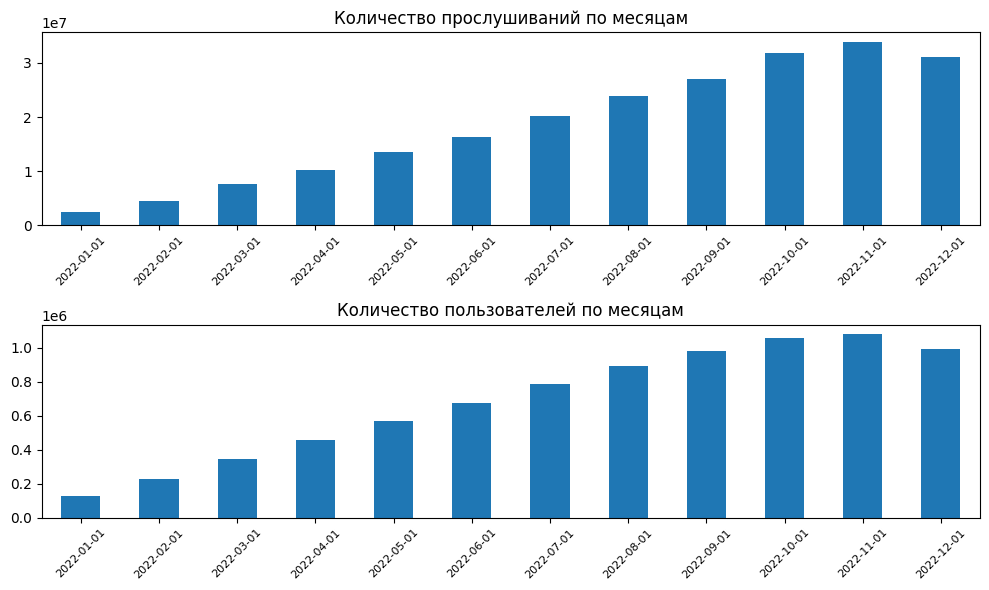

In [9]:
# Построим распределение по месяцам прослушивания

fig, axs = plt.subplots(2, 1, figsize=(10, 6))

ax = axs[0]
interactions_by_month["events"].plot(kind="bar", ax=ax)
ax.set_title('Количество прослушиваний по месяцам')
ax.set_xticklabels(interactions_by_month['started_at_month'], rotation=45)
ax.tick_params(axis='x', labelsize=8)

ax = axs[1]
interactions_by_month["users"].plot(kind="bar", ax=ax)
ax.set_title('Количество пользователей по месяцам')
ax.set_xticklabels(interactions_by_month['started_at_month'], rotation=45)
ax.tick_params(axis='x', labelsize=8)

fig.tight_layout()

Наиболее популярные треки. Сохраним топ-10 треков по количеству прослушиваний уникальными пользователями.

In [33]:
# Сохраним сргуппированные данные
top_10_tracks = interactions.groupby('track_id').agg(user_id_count = ('user_id', 'nunique'))\
                                                .sort_values('user_id_count', ascending=False)\
                                                .reset_index().head(10)

In [34]:
# Посмотрим на результат
top_10_tracks

,track_id,user_id_count
0,53404,111062
1,33311009,106921
2,178529,101924
3,35505245,99490
4,65851540,86670
5,24692821,86246
6,32947997,85886
7,51241318,85244
8,795836,85042
9,45499814,84748


In [36]:
# Присоединим названия треков
top_10_tracks = top_10_tracks.merge(catalog_names_clean.rename(columns={'id': 'track_id'}), on=['track_id'], how='left')

In [37]:
# Выведем 10 наиболее популярных треков
top_10_tracks

,track_id,user_id_count,type,name
0,53404,111062,track,Smells Like Teen Spirit
1,33311009,106921,track,Believer
2,178529,101924,track,Numb
3,35505245,99490,track,I Got Love
4,65851540,86670,track,Юность
5,24692821,86246,track,Way Down We Go
6,32947997,85886,track,Shape of You
7,51241318,85244,track,In The End
8,795836,85042,track,Shape Of My Heart
9,45499814,84748,track,Life


In [40]:
catalog_names_clean.type.unique()

array(['album', 'artist', 'genre', 'track'], dtype=object)

Наиболее популярные жанры

In [3]:
#tracks_clean = pd.read_parquet("data/tracks_clean.parquet")
catalog_names_clean = pd.read_parquet("data/catalog_names_clean.parquet")
interactions_cut = pd.read_parquet("data/interactions_cut.parquet")

Датасет с событиями занимает слишком много памяти, это непозволяет его обработать. Возьмем только данные по 50000 случайных пользователей.

In [22]:
# Сохраним список с случайными пользователями
users = random.sample(range(0,1374582),50000)

In [24]:
# Создадим усеченную версию датасета
interactions_cut = interactions[interactions['user_id'].isin(users)].reset_index(drop=True)

In [25]:
# Сохраним датасет для дальнейшей работы
interactions_cut.to_parquet('data/interactions_cut.parquet')

In [27]:
# Получается почти 8 миллионов строк вместо исходных 22
interactions_cut.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7995400 entries, 0 to 7995399
Data columns (total 4 columns):
 #   Column      Dtype         
---  ------      -----         
 0   user_id     int32         
 1   track_id    int32         
 2   track_seq   int16         
 3   started_at  datetime64[ns]
dtypes: datetime64[ns](1), int16(1), int32(2)
memory usage: 137.3 MB


In [ ]:
# Отберем только необходимые столбцы
tracks_clean_genres = tracks_clean[['track_id', 'genres']].explode('genres')

In [31]:
# Добавим к взаимодействиям информацию о жанрах
events_names = interactions_cut.merge(tracks_clean_genres, on=['track_id'], how='outer')

In [56]:
# Отберем популярные жанры
top_15_genres = events_names.groupby('genres').agg(user_id_count = ('user_id', 'nunique'))\
                                                           .sort_values('user_id_count', ascending=False)\
                                                           .reset_index().head(15)

In [57]:
# Сохраним только данные о жанрах
genres = catalog_names_clean[catalog_names_clean['type']=='genre'].reset_index(drop=True).rename(columns={'id': 'genres'})

In [58]:
# Выведем результат
top_15_genres.merge(genres, on='genres', how='left')

,genres,user_id_count,type,name
0,11,45800,genre,pop
1,75,36720,genre,rap
2,102,36427,genre,allrock
3,20,36328,genre,ruspop
4,16,34670,NaN,NaN
5,68,33430,genre,electronics
6,3,31123,NaN,NaN
7,14,29186,NaN,NaN
8,25,27310,genre,soundtrack
9,70,27131,genre,indie


Для некоторых жанров по id нет названия. Пропущенные расшифровки для id можно не удалять, поскольку численное кодирование позволит сохранить связи для рекомендаций.

Треки, которые никто не прослушал

In [4]:
# Сохраним только данные о треках
tracks = catalog_names_clean[catalog_names_clean['type']=='track'].reset_index(drop=True).rename(columns={'id': 'track_id'})

In [6]:
# Добавим ко всем трекам слушателей
df = tracks.merge(interactions, on='track_id', how='left')

In [10]:
# Выведем треки, для которых не нашлось слушателей
df[df['user_id'].isna()]

,track_id,type,name,user_id,track_seq,started_at
9,346,track,Night Songs,NaN,NaN,NaT
198,594,track,Peace Piece,NaN,NaN,NaT
199,599,track,Time Remembered,NaN,NaN,NaT
202,795,track,Dick Around,NaN,NaN,NaT
203,802,track,"Rock, Rock, Rock",NaN,NaN,NaT
...,...,...,...,...,...,...
8175372,101411944,track,Sleeping in the Cold Below,NaN,NaN,NaT
8175373,101418124,track,Пистолеты,NaN,NaN,NaT
8175374,101458360,track,KULT,NaN,NaN,NaT
8175378,101478482,track,На лицо,NaN,NaN,NaT


Поскольку целиком датасет обработать не представляется возможным на данный момент из-за нехватки ресурсов, будем считать, что для выбранных пользователей число непрослушанных треков достаточно большое. В основном датасете они скорее всего тоже есть.

# Преобразование данных

Преобразуем данные в формат, более пригодный для дальнейшего использования в расчётах рекомендаций. Для этого необходимо обработать датасет tracks_clean и объединить другие.

In [21]:
# Развернем списки в признаках по одному
tracks_exploded = tracks_clean.explode(['albums']).reset_index(drop=True)
tracks_exploded  = tracks_exploded.explode(['artists']).reset_index(drop=True)
tracks_exploded  = tracks_exploded.explode(['genres']).reset_index(drop=True)

In [25]:
# Преобразуем тип данных
tracks_exploded = tracks_exploded.astype('int')

In [35]:
catalog_names_clean.type.unique()

array(['album', 'artist', 'genre', 'track'], dtype=object)

In [40]:
# Разделим датасет catalog_names по типам
album = catalog_names_clean[catalog_names_clean['type']=='album'].rename(columns={'id':'albums', 'name': 'name_albums'})[['albums', 'name_albums']]
artist = catalog_names_clean[catalog_names_clean['type']=='artist'].rename(columns={'id':'artists', 'name': 'name_artists'})[['artists', 'name_artists']]
genre = catalog_names_clean[catalog_names_clean['type']=='genre'].rename(columns={'id':'genres', 'name': 'name_genres'})[['genres', 'name_genres']]
track = catalog_names_clean[catalog_names_clean['type']=='track'].rename(columns={'id':'track_id', 'name': 'name_track'})[['track_id', 'name_track']]

In [46]:
# Присоединим данные о треках
tracks_exploded = tracks_exploded.merge(track, on='track_id', how='left')
tracks_exploded = tracks_exploded.merge(album, on='albums', how='left')
tracks_exploded = tracks_exploded.merge(artist, on='artists', how='left')
tracks_exploded = tracks_exploded.merge(genre, on='genres', how='left')

In [ ]:
# Проверим пропуски
tracks_exploded.isna().sum()

track_id              0
albums                0
artists               0
genres                0
name_track       308923
name_albums          56
name_artists    1327551
name_genres     2458759
dtype: int64

Поскольку в данных о взаимодействиях пользователей есть только track_id, удалим данные о треке, где данных нет.

In [8]:
tracks_exploded.isna().sum()

track_id              0
albums                0
artists               0
genres                0
name_track       308923
name_albums          56
name_artists    1327551
name_genres     2458759
dtype: int64

In [ ]:
# Посмотрим, какое максимальное количество признаков есть для каждого трека
tracks_exploded['track_id'].value_counts().sort_values()

track_id
5815            1
5818            1
5824            1
5833            1
5838            1
            ...  
19214341     6656
18616440     6664
24337242     8397
36447403     9525
24254437    10116
Name: count, Length: 980977, dtype: int64

In [13]:
# Заполнение пропусков любым значением из столбца по track_id
def fill_na_with_group_values(df):
    # Применяем заполнение пропусков ко всем столбцам, кроме 'track_id'
    cols_to_fill = df.columns.difference(['track_id'])
    for col in cols_to_fill:
        df[col] = df[col].fillna(df[col].transform(lambda x: x.ffill().bfill()))
    return df

# Применяем функцию ко всему датасету
tracks_exploded_filled = fill_na_with_group_values(tracks_exploded)

In [ ]:
# Проверим результат
tracks_exploded_filled.isna().sum()

track_id        0
albums          0
artists         0
genres          0
name_track      0
name_albums     0
name_artists    0
name_genres     0
dtype: int64

Поскольку для каждого трека может быть большое количество (до 10116) дополнительных данных (жанр, альбом, исполнитель), оставим только по одному атрибуту (минимальное необходимое количество)

In [17]:
# Оставим только одну строку для каждого трека
tracks_exploded_filled_cut = tracks_exploded_filled.groupby('track_id').first().reset_index()

In [19]:
# Проверим пропуски
tracks_exploded_filled_cut.isna().sum().sort_values()

track_id        0
albums          0
artists         0
genres          0
name_track      0
name_albums     0
name_artists    0
name_genres     0
dtype: int64

In [20]:
# Посмотрим на итоговый датасет
tracks_exploded_filled_cut.sample(3)

,track_id,albums,artists,genres,name_track,name_albums,name_artists,name_genres
911318,80055440,14622782,3745035,13,Fault Line,EPIX,The Rigs,soundtrack
508873,35435577,4419014,668,11,Made For Me,To Be Continued...,Elton John,pop
84421,737380,81939,30349,38,One Thousand Days Of Sodom,In League With Satan,Bruce Dickinson,classicmetal


In [21]:
# Сохраним результат
tracks_exploded_filled_cut.to_parquet('data/tracks_exploded_filled_cut.parquet')

In [22]:
# Сохраним также вариант только с исходной числовой кодировкой
tracks_exploded_filled_cut[['track_id','albums','artists','genres']].to_parquet('data/tracks_exploded_filled_cut_enc.parquet')

In [53]:
# Исходный датасет также сохраним
tracks_exploded.to_parquet('data/tracks_exploded.parquet')

# Сохранение данных

Сохраним данные в двух файлах в персональном S3-бакете по пути `recsys/data/`:
- `items.parquet` — все данные о музыкальных треках,
- `events.parquet` — все данные о взаимодействиях.

In [26]:
# Переименуем датасет с всеми данными о музыкальных треках
items = tracks_exploded_filled_cut[['track_id','albums','artists','genres']].copy()

# Переименуем датасет с данными о взаимодействиях
events = interactions_cut.copy()

In [29]:
# Сохраним получившиеся датасеты
items.to_parquet('recsys/data/items.parquet')
events.to_parquet('recsys/data/events.parquet')

# Очистка памяти

Здесь, может понадобится очистка памяти для высвобождения ресурсов для выполнения кода ниже. 

Приведите соответствующие код, комментарии, например:
- код для удаление более ненужных переменных,
- комментарий, что следует перезапустить kernel, выполнить такие-то начальные секции и продолжить с этапа 3.

In [30]:
del tracks_exploded_filled_cut, tracks_exploded_filled, tracks_exploded, interactions_cut

# === ЭТАП 3 ===

# Загрузка данных

Если необходимо, то загружаем items.parquet, events.parquet.

In [ ]:
# Загружаем данные
items = pd.read_parquet('recsys/data/items.parquet')
events = pd.read_parquet('recsys/data/events.parquet')

# Разбиение данных

Разбиваем данные на тренировочную, тестовую выборки.

In [34]:
# зададим точку разбиения
train_test_global_time_split_date = pd.to_datetime("2022-12-16")

train_test_global_time_split_idx = events["started_at"] < train_test_global_time_split_date
events_train = events[train_test_global_time_split_idx]
events_test = events[~train_test_global_time_split_idx]

# количество пользователей в train и test
users_train = events_train["user_id"].drop_duplicates()
users_test = events_test["user_id"].drop_duplicates()

# количество пользователей, которые есть и в train, и в test
common_users = set(users_train).intersection(set(users_test))

print(len(users_train), len(users_test), len(common_users))

48826 28382 27252


In [35]:
# Холодные пользователи. Те кто есть в тест, но нет в трейн
cold_users = users_test[~users_test.isin(common_users)]

print(len(cold_users))

1130


In [38]:
# Сохраним датасеты
events_train.to_parquet('recsys/data/events_train.parquet')
events_test.to_parquet('recsys/data/events_test.parquet')

# Топ популярных

Рассчитаем рекомендации как топ популярных.

# Персональные

Рассчитаем персональные рекомендации.

# Похожие

Рассчитаем похожие, они позже пригодятся для онлайн-рекомендаций.

# Построение признаков

Построим три признака, можно больше, для ранжирующей модели.

# Ранжирование рекомендаций

Построим ранжирующую модель, чтобы сделать рекомендации более точными. Отранжируем рекомендации.

# Оценка качества

Проверим оценку качества трёх типов рекомендаций: 

- топ популярных,
- персональных, полученных при помощи ALS,
- итоговых
  
по четырем метрикам: recall, precision, coverage, novelty.

# === Выводы, метрики ===

Основные выводы при работе над расчётом рекомендаций, рассчитанные метрики.